# Implementing a GPT model from scratch to generate text

第四章的核心目标是把我们之前学过的所有单独的“零件”组装成一个完整的 GPT 模型。



![image.png](https://raw.githubusercontent.com/ipdor/Pictures/master/20260415161959247.png)

## 4.1 Coding an LLM architecture

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 词表大小
    "context_length": 1024, # 上下文长度
    "emb_dim": 768,         # 嵌入维度
    "n_heads": 12,          # 注意力头数
    "n_layers": 12,         # 层数
    "drop_rate": 0.1,       # Dropout 率
    "qkv_bias": False       # 查询-键-值偏置
}

在 `GPT_CONFIG_124M` 字典中，我们使用简洁的变量名以保持清晰并防止代码行过长：
* `vocab_size` 指的是 50,257 个词的词表，正如 BPE 分词器所使用的那样（见第 2 章）。
* `context_length` 表示模型通过位置嵌入能够处理的最大输入标记（token）数量（见第 2 章）。
* `emb_dim` 代表嵌入大小，将每个标记转换为一个 768 维的向量。
* `n_heads` 指示多头注意力机制中注意力头的数量（见第 3 章）。
* `n_layers` 指定模型中 Transformer 块的数量，我们将在接下来的讨论中介绍。
* `drop_rate` 指示 Dropout 机制的强度（0.1 意味着随机丢弃 10% 的隐藏单元）以防止过拟合（见第 3 章）。
* `qkv_bias` 决定是否在多头注意力的 `Linear` 层中包含用于查询、键和值计算的偏置向量。遵循现代大语言模型（LLM）的规范，我们最初会将其禁用，但在第 6 章将来自 OpenAI 的预训练 GPT-2 权重加载到我们的模型中时，我们将重新讨论它（见第 6 章）。

使用此配置，我们将实现一个 GPT 占位符架构（`DummyGPTModel`），如图 4.3 所示。这将为我们提供一个宏观视角，了解所有内容是如何组合在一起的，以及我们需要编写哪些其他组件来组装完整的 GPT 模型架构。

In [2]:
import torch 
import torch.nn as nn

In [3]:
cfg = GPT_CONFIG_124M
emb_dim = cfg["emb_dim"]
print(emb_dim)
print(nn.Embedding(cfg["vocab_size"], emb_dim))

768
Embedding(50257, 768)


第二章用过 `torch.nn.Embedding`

```class torch.nn.Embedding(num_embeddings, embedding_dim, ...)```

`torch.nn.Embedding` 本质上就是一个查找操作 (lookup operation)，它通过 token ID 从嵌入层的权重矩阵中检索出对应的行。

内部有 `[num_embeddings, embedding_dim]` 大小的权重矩阵，查找并返回输入 `tensor` 的各下标对应行

In [ ]:
embedding_layer = nn.Embedding(6, 2)
print(embedding_layer.weight.shape)
print(embedding_layer.weight)
print(embedding_layer(torch.tensor([1]))) # 查找 embedding_layer 第2行的ID

torch.Size([6, 2])
Parameter containing:
tensor([[-0.2464,  0.8240],
        [ 0.1955, -1.4382],
        [-0.9752,  0.7291],
        [-0.5781,  0.7350],
        [ 1.0977,  0.4639],
        [-1.2886,  0.3471]], requires_grad=True)
tensor([[ 0.1955, -1.4382]], grad_fn=<EmbeddingBackward0>)


In [5]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Embedding(a,b) 就是建立 a个token ID，每个ID有b个维度。供后面查询
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) # positional embedding
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential( # 为 TransformerBlock 使用占位符
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"]) # 为 final layer normalization 使用占位符
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # Linear output layer

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        # Token IDs -> Token embeddings
        # 查找 tok_emb对应in_idx位置的IDs, 和pos_emb中前seq_len个ID
        tok_embeds = self.tok_emb(in_idx) # [batch_size, seq_len, emb_dim]
        pos_embeds = self.pos_emb(  # [seq_len, emb_dim]
            torch.arange(seq_len, device=in_idx.device)
        )
        # 转换为emb tokens 并且加上 pos emb 
        x = tok_embeds + pos_embeds # [batch_size, seq_len, emb_dim]
        x = self.drop_emb(x)
        x = self.trf_blocks(x) # 输入 transformer 块中
        x = self.final_norm(x) # 层归一化
        logits = self.out_head(x) # 线性输出层 # [batch_size, seq_len, vocab_size]
        return logits

In [ ]:
# 一个简单的占位符类，稍后将被真正的 TransformerBlock 替换, 
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x

In [ ]:
# 一个简单的占位符类，稍后将被真正的 LayerNorm 替换, final layer normalization
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

```class torch.nn.Sequential(*args: Module)```

一个顺序容器 [Description](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)

作为`pipeline`，它把多个 nn.Module 组合成一个新的 nn.Module。模块会被按传入构造函数的顺序添加，前一个模块的输出会作为下一个的输入，最后一个模块的输出作为最终输出。用处是将多个模块视为一个单一的模块

In [ ]:
# *[]的作用是解包获得列表内所有元素
lst = ["a", "b", "c"]
print(lst)
print(*lst)

# 如果不加* Sequential的参数是一个list，不是多个模块，会报错
trf_blocks = nn.Sequential(
    *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
)
print(trf_blocks)

['a', 'b', 'c']
a b c
Sequential(
  (0): DummyTransformerBlock()
  (1): DummyTransformerBlock()
  (2): DummyTransformerBlock()
  (3): DummyTransformerBlock()
  (4): DummyTransformerBlock()
  (5): DummyTransformerBlock()
  (6): DummyTransformerBlock()
  (7): DummyTransformerBlock()
  (8): DummyTransformerBlock()
  (9): DummyTransformerBlock()
  (10): DummyTransformerBlock()
  (11): DummyTransformerBlock()
)


准备输入数据并初始化一个新的 GPT 模型以说明其用法

In [9]:
import tiktoken

In [10]:
# input text -> Tokenized text -> Token IDs
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
# print(torch.tensor(batch)) # 不能用这种方式转tensor, torch.tensor() 不接受“tensor的list”作为输入， 否则会把 tensor 当成数字下标解析，导致报错
batch = torch.stack(batch, dim=0) # torch.stack 要求shape完全一样才可以，否则报错
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


![image.png](https://raw.githubusercontent.com/ipdor/Pictures/master/20260416211253944.png)

嵌入维度emb_dim=768，并且在 LLM 中，嵌入的输入 token 维度通常与输出维度匹配，所以每次GPT模型的单个输入和输出token都是768维；

LLM输入和输出 token 个数相同，所以输出会多出预测的下个单词token、省略掉第一个输入token

In [11]:
# 初始化一个新的 1.24 亿参数的 `DummyGPTModel` 实例
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


输出维度[2, 4, 50257]

2批，对应输入的2句话   
4行，对应每句话的4个token   
50257列，每个token对应50257个词汇量

Postprocessing流程:   50257维 向量 -> token IDs -> 单词

## 4.2 Normalizing activations with layer normalization

由于梯度消失或梯度爆炸等问题，训练具有许多层的深度神经网络有时会被证明具有挑战性。这些问题会导致不稳定的训练动态，并使网络难以有效地调整其权重，这意味着学习过程难以找到一组能够最小化损失函数的神经网络参数（权重）。换句话说，网络很难在足够高的程度上学习数据中的潜在模式，从而使其能够做出准确的预测或决策。

附录 A 的 A.4 节有对神经网络训练和梯度的概念的简要介绍

实现**层归一化**能提高神经网络训练的稳定性和效率。层归一化背后的主要思想是调整神经网络层的激活（输出），使其均值为 0，方差为 1，这也称为单位方差。

层归一化通常应用于多头注意力模块之前和之后，并且在 final output layer 之前

![image.png](https://raw.githubusercontent.com/ipdor/Pictures/master/20260416215214727.png)

In [12]:
torch.manual_seed(123)
batch_example = torch.randn(2,5) # 创建两个训练样本，每个样本具有五个维度（特征）
#print(batch_example)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
#print(nn.Linear(5,6).weight)
out = layer(batch_example) # [2,5] * [5,6] + bias -> ReLU([2,6])
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


神经网络层包含：  
1. Linear 层  
2. 非线性激活函数ReLU(rectified linear unit 修正线性单元)

其中 `ReLU` 作用是把负输入阈值化为 0，确保层只输出正值

In [13]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


在均值或方差计算等操作中：

使用 `keepdim=True` 可以确保输出张量保留与输入张量相同的维度数量，即使该操作沿着通过 dim 指定的维度缩减了张量。

`dim` 指定怎么执行统计计算。 对于二维张量， `dim=0` across the row dimension 跨行统计各列的数值； `dim=1`
or `dim=-1` across the column dimension 跨列计算各行的数值。

In [14]:
# 归一化，减去均值并除以方差（也称为标准差）的平方根
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [ ]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


层归一化对最后一个维度操作，其代表嵌入维度 `em_dim`   
变量 `eps` 是一个在归一化过程中加到方差上的小常数（epsilon），以防止除以零。
`scale` 和 `shift` 是两个可训练参数（与输入具有相同的维度），如果确定这样做可以提高模型在其训练任务上的性能，LLM 会在训练期间自动调整它们。

默认使用贝塞尔校正（Bessel's correction），因为在分母中使用 `n – 1` 而不是 `n`,所以叫做有偏估计：
```
unbiased=True
```
即：

$$\frac{1}{N-1}$$

而 LayerNorm 使用的是：

$$\frac{1}{N}$$

也就是
```
unbiased=False
```
实际在大模型中由于N非常大，这两种计算方式的差异可以忽略。这里是为了和GPT-2模型保持一致而选择 `unbiased=False`


In [16]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [17]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Unlike batch normalization, which normalizes across the batch dimension, layer normalization normalizes across the feature dimension.  
与批归一化在批处理维度上进行归一化不同，层归一化在特征维度上进行归一化。

## 4.3 Implementing a feed forward network with GELU activations

In [18]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5*x* (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi)) * (x+0.044715*x**3)
        ))

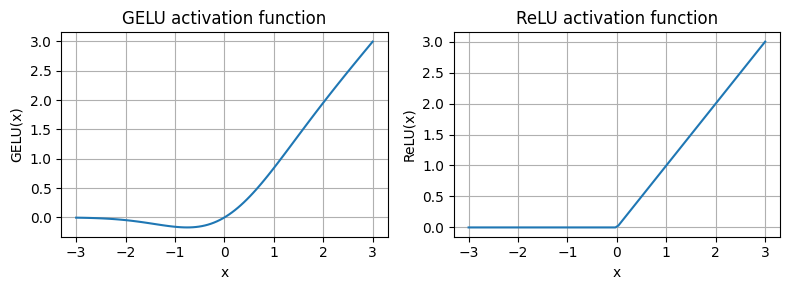

In [19]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize = (8,3))
for i, (y,label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(                        # [2,3,768]
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),    # in:[2,3,768], out:[2,3,3072]
            GELU(),                                         # in, out:[2,3,3072]
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"])     # in:[2,3,3072], out:[2,3,768]
        )

    def forward(self, x):
        return self.layers(x)

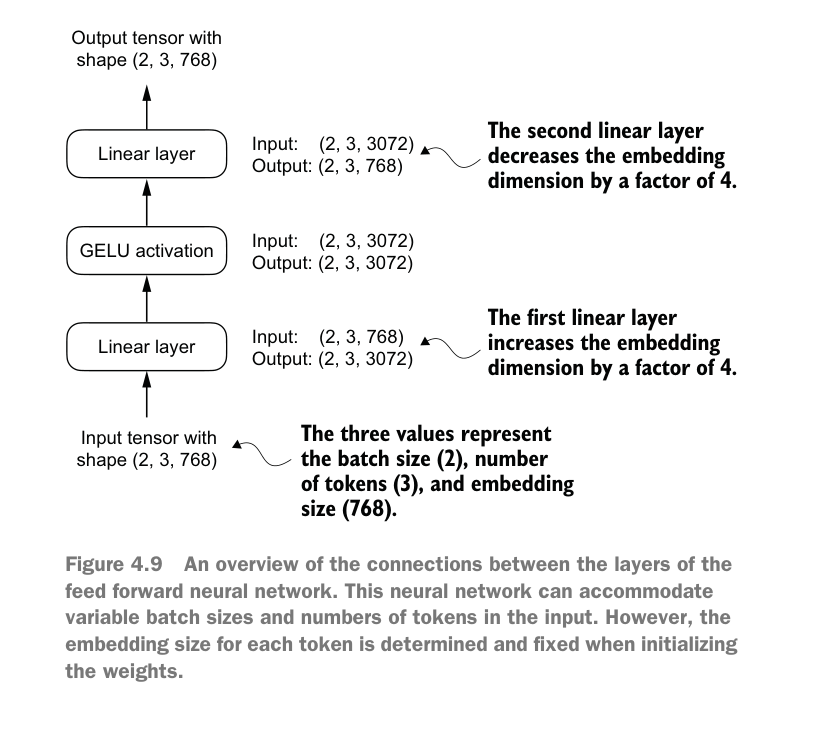

In [21]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


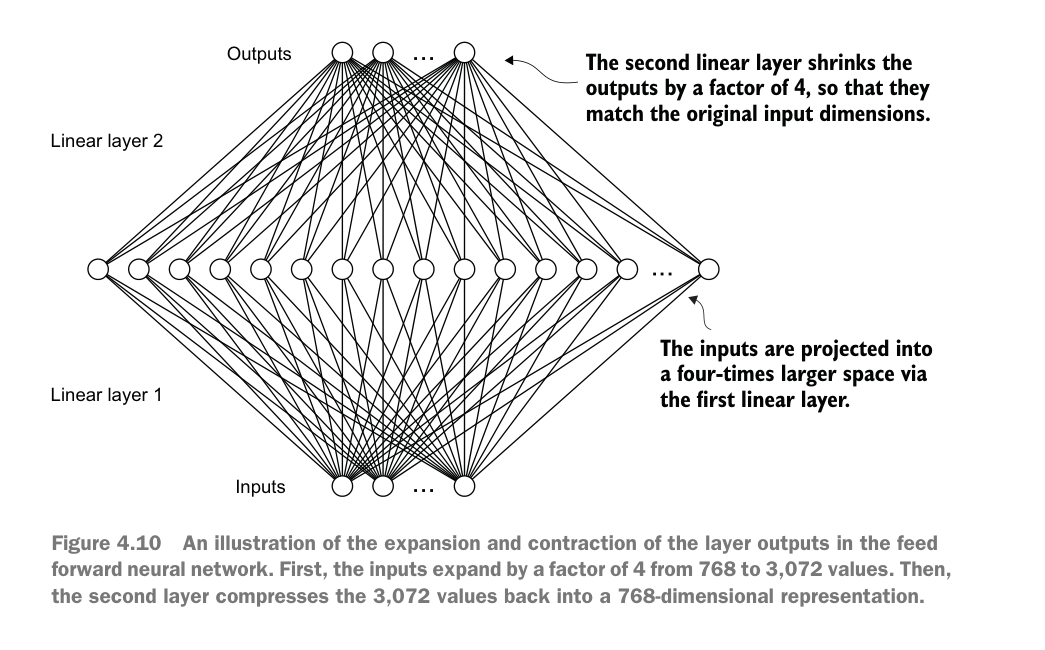

这个小型的神经网络输入输出维度相同，但是第一层把embedding size扩展4倍，然后使用 `GELU` 激活，最后再缩放回原来大小。这种设计允许探索更丰富的表示空间。

此外，输入和输出维度的统一性通过允许堆叠多个层（正如我们稍后将要做的）来简化架构，而无需在它们之间调整维度，从而使模型更具可扩展性。

## 4.4 Adding shortcut connections

In [22]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            # 每一层有 weight 和 bias， 来自Linear
            # weight大小[a,b], bias[1,b]
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])
    
    def forward(self, x):
        # ModuleList 不会像Sequential 那样自动传递，需要手动 forward
        for layer in self.layers:
            layer_output = layer(x) # 当前层输出
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output # 如果用捷径，x = 当前层输出f(x) + 上一层输出x
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # 正向传递
    output = model(x)
    target = torch.tensor([[0.]])
    # 根据目标和输出的接近程度计算损失
    loss = nn.MSELoss()
    loss = loss(output, target)
    # 后向传递以计算梯度
    loss.backward()

    for name, param in model.named_parameters():
        #print(f"name = {name}, param= {param}")
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [23]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)

model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


`print_gradients` 函数的输出显示，随着我们从最后一层（`layers.4`）向第一层（`layers.0`）前进，梯度变得越来越小，这是一种称为梯度消失问题（`vanishing gradient problem`）的现象。

In [24]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


使用 `shortcut connection` 后，尽管 `layers.4` 仍然有更大的梯度，但是它前进到 `layers.0` 的梯度值逐渐稳定，没有缩小到一个极其微小的值。

## 4.5 Connecting attention and linear layers in a transformer block